In [1]:
import math
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("../Data/processed/nasa_workload_5min.csv")

df.head()

# Reactive Auto-Scaling Simulator

Baseline simulator for target-tracking reactive scaling using 5-minute workload data.

Goals:
- simulate instance scaling over time
- measure SLA violations
- estimate utilization and cost
- create a baseline for later predictive and hybrid comparison

In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../Data/processed/nasa_workload_clean_5min.csv", parse_dates=["timestamp"])
df.head()

,timestamp,requests,demand
0,1995-08-01 00:00:00,220.0,33.59
1,1995-08-01 00:05:00,159.0,24.27
2,1995-08-01 00:10:00,102.0,15.57
3,1995-08-01 00:15:00,74.0,11.30
4,1995-08-01 00:20:00,143.0,21.83


In [4]:
print(df.shape)
print(df.columns)
df.info()

(8928, 3)
Index(['timestamp', 'requests', 'demand'], dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 8928 entries, 0 to 8927
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  8928 non-null   datetime64[us]
 1   requests   8928 non-null   float64       
 2   demand     8928 non-null   float64       
dtypes: datetime64[us](1), float64(2)
memory usage: 209.4 KB


In [5]:
df[["timestamp", "demand"]].head(10)

,timestamp,demand
0,1995-08-01 00:00:00,33.59
1,1995-08-01 00:05:00,24.27
2,1995-08-01 00:10:00,15.57
3,1995-08-01 00:15:00,11.30
4,1995-08-01 00:20:00,21.83
5,1995-08-01 00:25:00,15.11
6,1995-08-01 00:30:00,18.47
7,1995-08-01 00:35:00,32.06
8,1995-08-01 00:40:00,26.11
9,1995-08-01 00:45:00,17.56


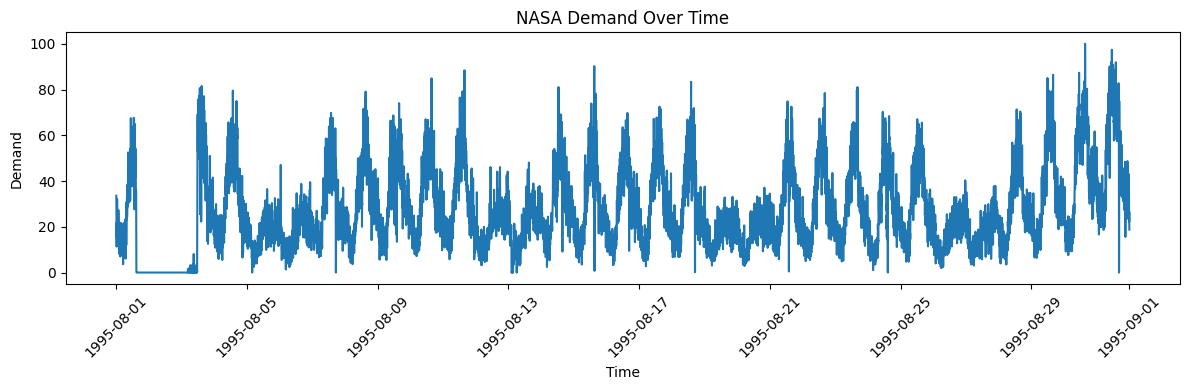

In [6]:
plt.figure(figsize=(12,4))
plt.plot(df["timestamp"], df["demand"])
plt.title("NASA Demand Over Time")
plt.xlabel("Time")
plt.ylabel("Demand")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
params = {
    "capacity_per_instance": 100,
    "target_utilization": 0.60,
    "provisioning_delay_steps": 2,
    "cooldown_steps": 2,
    "min_instances": 1,
    "max_instances": 20,
    "initial_instances": 1,
    "cost_per_instance_step": 1.0
}

In [8]:
params

{'capacity_per_instance': 100,
 'target_utilization': 0.6,
 'provisioning_delay_steps': 2,
 'cooldown_steps': 2,
 'min_instances': 1,
 'max_instances': 20,
 'initial_instances': 1,
 'cost_per_instance_step': 1.0}

In [9]:
instances = params["initial_instances"]
pending_scale_out = []
cooldown_remaining = 0
cumulative_cost = 0.0

print("instances:", instances)
print("pending_scale_out:", pending_scale_out)
print("cooldown_remaining:", cooldown_remaining)
print("cumulative_cost:", cumulative_cost)

instances: 1
pending_scale_out: []
cooldown_remaining: 0
cumulative_cost: 0.0


In [10]:
row = df.iloc[0]

timestamp = row["timestamp"]
demand = float(row["demand"])

capacity = instances * params["capacity_per_instance"]
utilization = demand / capacity if capacity > 0 else 0.0

desired_instances = math.ceil(
    demand / (params["capacity_per_instance"] * params["target_utilization"])
) if demand > 0 else params["min_instances"]

desired_instances = max(params["min_instances"], min(desired_instances, params["max_instances"]))

sla_violation = 1 if demand > capacity else 0
unserved_demand = max(0.0, demand - capacity)

print("timestamp:", timestamp)
print("demand:", demand)
print("capacity:", capacity)
print("utilization:", utilization)
print("desired_instances:", desired_instances)
print("sla_violation:", sla_violation)
print("unserved_demand:", unserved_demand)

timestamp: 1995-08-01 00:00:00
demand: 33.59
capacity: 100
utilization: 0.33590000000000003
desired_instances: 1
sla_violation: 0
unserved_demand: 0.0


In [11]:
results = []

instances = params["initial_instances"]
cumulative_cost = 0.0

for _, row in df.iterrows():
    timestamp = row["timestamp"]
    demand = float(row["demand"])

    capacity = instances * params["capacity_per_instance"]
    utilization = demand / capacity if capacity > 0 else 0.0

    desired_instances = math.ceil(
        demand / (params["capacity_per_instance"] * params["target_utilization"])
    ) if demand > 0 else params["min_instances"]

    desired_instances = max(
        params["min_instances"],
        min(desired_instances, params["max_instances"])
    )

    sla_violation = 1 if demand > capacity else 0
    unserved_demand = max(0.0, demand - capacity)

    step_cost = instances * params["cost_per_instance_step"]
    cumulative_cost += step_cost

    results.append({
        "timestamp": timestamp,
        "demand": demand,
        "instances": instances,
        "capacity": capacity,
        "utilization": utilization,
        "desired_instances": desired_instances,
        "sla_violation": sla_violation,
        "unserved_demand": unserved_demand,
        "step_cost": step_cost,
        "cumulative_cost": cumulative_cost
    })

In [12]:
results_df = pd.DataFrame(results)
results_df.head()

,timestamp,demand,instances,capacity,utilization,desired_instances,sla_violation,unserved_demand,step_cost,cumulative_cost
0,1995-08-01 00:00:00,33.59,1,100,0.3359,1,0,0.0,1.0,1.0
1,1995-08-01 00:05:00,24.27,1,100,0.2427,1,0,0.0,1.0,2.0
2,1995-08-01 00:10:00,15.57,1,100,0.1557,1,0,0.0,1.0,3.0
3,1995-08-01 00:15:00,11.30,1,100,0.1130,1,0,0.0,1.0,4.0
4,1995-08-01 00:20:00,21.83,1,100,0.2183,1,0,0.0,1.0,5.0


In [13]:
print(results_df.shape)
print(results_df.columns.tolist())

(8928, 10)
['timestamp', 'demand', 'instances', 'capacity', 'utilization', 'desired_instances', 'sla_violation', 'unserved_demand', 'step_cost', 'cumulative_cost']


In [14]:
print("SLA violation rate:", results_df["sla_violation"].mean())
print("Average utilization:", results_df["utilization"].mean())
print("Total cost:", results_df["cumulative_cost"].iloc[-1])

SLA violation rate: 0.0
Average utilization: 0.2684581205197133
Total cost: 8928.0


In [15]:
results = []

instances = params["initial_instances"]
cumulative_cost = 0.0

for _, row in df.iterrows():
    timestamp = row["timestamp"]
    demand = float(row["demand"])

    # current available capacity from active instances
    capacity = instances * params["capacity_per_instance"]

    # how busy the current system is
    utilization = demand / capacity if capacity > 0 else 0.0

    # number of instances needed to keep utilization near target
    desired_instances = math.ceil(
        demand / (params["capacity_per_instance"] * params["target_utilization"])
    ) if demand > 0 else params["min_instances"]

    # keep instance count within allowed bounds
    desired_instances = max(
        params["min_instances"],
        min(desired_instances, params["max_instances"])
    )

    # reactive scaling decision: adjust active instances immediately
    if desired_instances > instances:
        instances = desired_instances
    elif desired_instances < instances:
        instances = desired_instances

    # recalculate capacity after scaling, otherwise stored capacity will be old
    capacity = instances * params["capacity_per_instance"]

    # recalculate utilization after scaling for the same reason
    utilization = demand / capacity if capacity > 0 else 0.0

    # SLA check: demand above capacity means service failure/shortage
    sla_violation = 1 if demand > capacity else 0

    # amount of demand the system could not serve
    unserved_demand = max(0.0, demand - capacity)

    # simplified infrastructure cost for this timestep
    step_cost = instances * params["cost_per_instance_step"]
    cumulative_cost += step_cost

    # store timestep result so we can evaluate and plot later
    results.append({
        "timestamp": timestamp,
        "demand": demand,
        "instances": instances,
        "capacity": capacity,
        "utilization": utilization,
        "desired_instances": desired_instances,
        "sla_violation": sla_violation,
        "unserved_demand": unserved_demand,
        "step_cost": step_cost,
        "cumulative_cost": cumulative_cost
    })

results_df = pd.DataFrame(results)
results_df.head()

,timestamp,demand,instances,capacity,utilization,desired_instances,sla_violation,unserved_demand,step_cost,cumulative_cost
0,1995-08-01 00:00:00,33.59,1,100,0.3359,1,0,0.0,1.0,1.0
1,1995-08-01 00:05:00,24.27,1,100,0.2427,1,0,0.0,1.0,2.0
2,1995-08-01 00:10:00,15.57,1,100,0.1557,1,0,0.0,1.0,3.0
3,1995-08-01 00:15:00,11.30,1,100,0.1130,1,0,0.0,1.0,4.0
4,1995-08-01 00:20:00,21.83,1,100,0.2183,1,0,0.0,1.0,5.0


In [16]:
print(results_df[["instances", "capacity", "desired_instances"]].head(10))
print("Unique instance counts:", results_df["instances"].nunique())
print("SLA violation rate:", results_df["sla_violation"].mean())
print("Average utilization:", results_df["utilization"].mean())
print("Total cost:", results_df["cumulative_cost"].iloc[-1])

   instances  capacity  desired_instances
0          1       100                  1
1          1       100                  1
2          1       100                  1
3          1       100                  1
4          1       100                  1
5          1       100                  1
6          1       100                  1
7          1       100                  1
8          1       100                  1
9          1       100                  1
Unique instance counts: 2
SLA violation rate: 0.0
Average utilization: 0.2505315132168459
Total cost: 9395.0
